<style>
/* Typography-only update: matches Avance2_CAT */
.jp-RenderedHTMLCommon,
.jp-RenderedMarkdown,
.jp-MarkdownOutput {
  font-family: "Palatino Linotype", "Book Antiqua", Palatino, "Times New Roman", serif;
  line-height: 1.6;
  letter-spacing: 0.1px;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.jp-RenderedMarkdown h1,
.jp-RenderedMarkdown h2,
.jp-RenderedMarkdown h3 {
  font-family: "Segoe UI", "Trebuchet MS", "Gill Sans", sans-serif;
  font-weight: 700;
  letter-spacing: 0.2px;
}
.jp-RenderedHTMLCommon code,
.jp-RenderedMarkdown code,
.jp-RenderedHTMLCommon pre,
.jp-RenderedMarkdown pre {
  font-family: Consolas, "Cascadia Mono", "Courier New", monospace;
}
</style>

# 4) Extended Model Benchmark — six classifiers on filtered features vs. PCA scores

Fourth stage of the availability pipeline. We reuse the two parquet files
produced by `Avance2_CAT` and follow the same evaluation protocol as
`Avance3_CAT`, but the *Dummy* baseline is removed and the model lineup is
widened to **six varied classifiers** trained in parallel on each feature set:

- `{SERIAL_NUMBER}_Features.parquet`     — filtered raw channels + `Status`
- `{SERIAL_NUMBER}_PCA_scores.parquet`   — PCA scores

## Academic objectives
**4.1** Broaden the algorithmic comparison from the baseline stage.

**4.2** Identify a short list of candidate models for hyper-parameter tuning.

## Models compared (no Dummy this time)
1. **Logistic Regression** — linear, interpretable, scaled features.
2. **Random Forest** — bagged trees, robust, built-in importance.
3. **XGBoost** — gradient-boosted trees, strong tabular baseline.
4. **Gradient Boosting (sklearn)** — boosted trees, different implementation.
5. **Quadratic Discriminant Analysis (QDA)** — generative Gaussian-per-class model, quadratic decision boundary.
6. **Multi-Layer Perceptron** — feed-forward neural network, scaled features.

## Plan
1. Load both feature sets produced by Avance 2 (row-aligned by `date_time`).
2. Build a **time-aware split** (first ~70% train, last ~30% test).
3. **Undersample the training set only** to balance the classes.
4. Train the six classifiers on **each** representation.
5. Report metrics, confusion matrices, ROC curves, feature importance and
   learning curves **side-by-side**.
6. Persist the combined comparison table for the next stage.

## 0. Imports and configuration

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import learning_curve, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42
SERIAL_NUMBER = "M9P00224"   # same machine used in Avance2_CAT / Avance3_CAT
TARGET = "Status"
POSITIVE_LABEL = "not_working"   # downtime class we want to detect

FEATURES_FILE = Path(f"{SERIAL_NUMBER}_Features.parquet")
PCA_FILE      = Path(f"{SERIAL_NUMBER}_PCA_scores.parquet")

print("Features parquet exists:", FEATURES_FILE.exists(), "->", FEATURES_FILE)
print("PCA parquet exists:     ", PCA_FILE.exists(), "->", PCA_FILE)


class XGBStringWrapper(BaseEstimator, ClassifierMixin):
    """Thin wrapper so XGBClassifier accepts the string Status labels used
    everywhere else in the notebook (evaluate_model, classification_report, ...)."""

    def __init__(self, **xgb_kwargs):
        self.xgb_kwargs = xgb_kwargs

    def fit(self, X, y):
        self._le = LabelEncoder().fit(y)
        self.classes_ = self._le.classes_
        self._model = XGBClassifier(**self.xgb_kwargs)
        self._model.fit(X, self._le.transform(y))
        return self

    def predict(self, X):
        return self._le.inverse_transform(self._model.predict(X))

    def predict_proba(self, X):
        return self._model.predict_proba(X)

    @property
    def feature_importances_(self):
        return self._model.feature_importances_

Features parquet exists: True -> M9P00224_Features.parquet
PCA parquet exists:      True -> M9P00224_PCA_scores.parquet


## 1. Load the two feature sets from Avance 2

In [2]:
df_feat = pd.read_parquet(FEATURES_FILE)
df_pca  = pd.read_parquet(PCA_FILE)

# Sort by time so the time-aware split is meaningful
for d in (df_feat, df_pca):
    if "date_time" in d.columns:
        d.sort_values("date_time", inplace=True)
        d.reset_index(drop=True, inplace=True)

# Copy Status from df_feat into df_pca (row-aligned)
df_pca[TARGET] = df_feat[TARGET].values

print(f"Filtered-features dataset:  {df_feat.shape}")
print(f"PCA-features dataset:       {df_pca.shape}")

print("\nClass balance (filtered features):")
print(df_feat[TARGET].value_counts(normalize=True).round(3))

print("\nClass balance (PCA features):")
print(df_pca[TARGET].value_counts(normalize=True).round(3))

df_feat.head(3)

Filtered-features dataset:  (1257373, 60)
PCA-features dataset:       (1257373, 31)

Class balance (filtered features):
Status
working        0.784
not_working    0.216
Name: proportion, dtype: float64

Class balance (PCA features):
Status
working        0.784
not_working    0.216
Name: proportion, dtype: float64


,GLOBAL_TIME,___valve_lift_percent,___valve_tilt_percent,AIC_Active_Stat,Air_Filter_Restr_1,ATMPRES,BKT_ANGLE,calc_pump_flow,calc_pump_flow_ave,ceal_sensor_temp_exhaust_left,...,SPD_XMSN_IN,STAT_VLV_LIFT,STAT_VLV_TILT,sterm_moving_avg,TC_OUT_TORQ,TMP_AXL_OIL_F,TMP_HYD_OIL,total_pump_displacement,date_time,Status
0,99852.000000,0.0,0.0,0.0,1.59375,99.78125,42.041754,705751.0,53919.0,553.4375,...,953.875,0.0,0.0,64428.0,2027.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.029000,working
1,99852.000002,0.0,0.0,0.0,1.50000,99.78125,42.018315,705751.0,53919.0,553.4375,...,947.250,0.0,0.0,64428.0,2004.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.148999,working
2,99852.000003,0.0,0.0,0.0,1.50000,99.78125,42.002689,705751.0,53919.0,553.4375,...,981.000,0.0,0.0,64428.0,1952.0,54.75,60.871084,32512.0,2026-02-01 00:00:00.269000,working


## 2. Helper functions

Same helpers as in Avance 3:

- `split_xy` — extract `X`, `y` and apply a **time-ordered** 70/30 split.
- `evaluate_model` — fit, predict and return a compact metrics row + the
  fitted estimator for later inspection.

In [3]:
DROP_COLS = {TARGET, "date_time", "GLOBAL_TIME"}

def split_xy(frame: pd.DataFrame, test_frac: float = 0.30):
    """Time-ordered train/test split (no shuffling)."""
    feature_cols = [c for c in frame.columns if c not in DROP_COLS]
    X = frame[feature_cols].select_dtypes(include=[np.number]).copy()
    y = frame[TARGET].astype(str).copy()

    n_test = int(len(frame) * test_frac)
    X_train, X_test = X.iloc[:-n_test], X.iloc[-n_test:]
    y_train, y_test = y.iloc[:-n_test], y.iloc[-n_test:]
    return X_train, X_test, y_train, y_test, feature_cols


def evaluate_model(name: str, model, X_train, X_test, y_train, y_test,
                   positive_label: str = POSITIVE_LABEL):
    """Fit, predict, score. Returns (row_dict, fitted_model, y_pred, y_proba)."""
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred       = model.predict(X_test)

    classes = list(model.classes_)
    y_proba = None
    roc_auc = np.nan
    if hasattr(model, "predict_proba") and positive_label in classes:
        y_proba = model.predict_proba(X_test)[:, classes.index(positive_label)]
        try:
            roc_auc = roc_auc_score((y_test == positive_label).astype(int), y_proba)
        except ValueError:
            roc_auc = np.nan
    elif hasattr(model, "decision_function") and positive_label in classes:
        # SVC(probability=False) path: use decision_function as a score.
        scores = model.decision_function(X_test)
        if scores.ndim == 2:
            scores = scores[:, classes.index(positive_label)]
        y_proba = scores
        try:
            roc_auc = roc_auc_score((y_test == positive_label).astype(int), scores)
        except ValueError:
            roc_auc = np.nan

    row = {
        "model": name,
        "acc_train":      accuracy_score(y_train, y_pred_train),
        "acc_test":       accuracy_score(y_test,  y_pred),
        "bal_acc_test":   balanced_accuracy_score(y_test, y_pred),
        "f1_macro_test":  f1_score(y_test, y_pred, average="macro"),
        "precision_pos":  precision_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "recall_pos":     recall_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "f1_pos":         f1_score(y_test, y_pred, pos_label=positive_label, zero_division=0),
        "roc_auc":        roc_auc,
    }
    return row, model, y_pred, y_proba

## 3. Time-aware split and training-only class balancing

For each feature set we build the chronological 70/30 split and undersample
**only the training set** (test set stays untouched, preserving the natural
class prevalence the model will face on real machine data).

In [4]:
DATASETS = [("filtered", df_feat), ("pca", df_pca)]
splits = {}

for name, df in DATASETS:
    X_tr, X_te, y_tr, y_te, cols = split_xy(df)

    # Undersample majority classes in the TRAINING set only
    min_count = y_tr.value_counts().min()
    balanced_idx = (
        y_tr.groupby(y_tr, group_keys=False)
            .apply(lambda s: s.sample(n=min_count, random_state=RANDOM_STATE))
            .index
            .sort_values()  # keep chronological order
    )
    X_tr = X_tr.loc[balanced_idx]
    y_tr = y_tr.loc[balanced_idx]

    splits[name] = {"X_train": X_tr, "X_test": X_te,
                    "y_train": y_tr, "y_test": y_te,
                    "cols": cols}
    print(f"[{name:8s}] train={len(X_tr):,} | test={len(X_te):,} | features={X_tr.shape[1]}")
    print(f"[{name:8s}] balanced train classes: {dict(y_tr.value_counts())}\n")

[filtered] train=367,828 | test=377,211 | features=57
[filtered] balanced train classes: {'working': np.int64(183914), 'not_working': np.int64(183914)}

[pca     ] train=367,828 | test=377,211 | features=30
[pca     ] balanced train classes: {'working': np.int64(183914), 'not_working': np.int64(183914)}



## 4. Six classifiers on each feature set

Six varied learners trained **once per feature set**:

- **Logistic Regression** (scaled) — linear baseline.
- **Random Forest** (200 trees, balanced class weight).
- **XGBoost** (300 trees, `scale_pos_weight` for residual imbalance).
- **Gradient Boosting** (sklearn implementation, 200 estimators).
- **Quadratic Discriminant Analysis (QDA)** (scaled features, small ridge on class covariances).
- **MLP** (one hidden layer, scaled features).

Results, fitted estimators and predictions are stored in dictionaries keyed by
`"filtered"` / `"pca"` so the rest of the notebook can render side-by-side
plots.

In [5]:
from sklearn import svm


def build_models(spw: float):
    """Factory: fresh estimators for one feature set (spw depends on train balance)."""
    logreg = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2_000,
                                   class_weight="balanced",
                                   random_state=RANDOM_STATE)),
    ])
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=20, n_jobs=-1,
        class_weight="balanced", random_state=RANDOM_STATE,
    )
    xgb = XGBStringWrapper(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.9, colsample_bytree=0.9,
        objective="binary:logistic", eval_metric="logloss",
        tree_method="hist", scale_pos_weight=spw,
        n_jobs=-1, random_state=RANDOM_STATE,
    )
    gb = GradientBoostingClassifier(
        # sklearn's GB is single-threaded; keep it small so it doesn't
        # dominate the cell. For real tuning, use HistGradientBoosting.
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8,
        random_state=RANDOM_STATE,
    )
    # Quadratic Discriminant Analysis: generative Gaussian-per-class model
    # with its own covariance per class -> a quadratic (non-linear) decision
    # boundary. Trains in milliseconds and exposes predict_proba.
    # `reg_param` adds a small ridge to the class covariances for numerical
    # stability on (near-)collinear telemetry features.
    qda = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    QuadraticDiscriminantAnalysis(reg_param=1e-3)),
    ])

    return [
        ("logreg", "Logistic Regression", logreg),
        ("rf",     "Random Forest",       rf),
        ("xgb",    "XGBoost",             xgb),
        ("gb",     "Gradient Boosting",   gb),
        ("qda",    "QDA",                 qda),
    ]


# --------------------------------------------------------------------
# Train every model on every feature set and collect results
# --------------------------------------------------------------------
fitted  = {name: {} for name, _ in DATASETS}   # {feat_set: {model_key: estimator}}
preds   = {name: {} for name, _ in DATASETS}   # {feat_set: {model_key: (y_pred, y_proba)}}
results = []

for name, _ in DATASETS:
    S = splits[name]
    y_tr_bin = (S["y_train"] == POSITIVE_LABEL).astype(int)
    neg, pos = (y_tr_bin == 0).sum(), (y_tr_bin == 1).sum()
    spw = float(neg) / float(pos) if pos > 0 else 1.0

    for model_key, model_label, est in build_models(spw):
        row, fitted_est, y_pred, y_proba = evaluate_model(
            f"{model_label} [{name}]", est,
            S["X_train"], S["X_test"],
            S["y_train"], S["y_test"],
        )
        fitted[name][model_key] = fitted_est
        preds[name][model_key]  = (y_pred, y_proba)
        results.append(row)
        print(f"[{name:8s}] {model_label:20s} "
              f"f1_macro={row['f1_macro_test']:.3f}  "
              f"bal_acc={row['bal_acc_test']:.3f}  "
              f"roc_auc={row['roc_auc']:.3f}")

results_df = pd.DataFrame(results).set_index("model").round(4)
display(results_df)

[filtered] Logistic Regression  f1_macro=0.830  bal_acc=0.822  roc_auc=0.918
[filtered] Random Forest        f1_macro=0.703  bal_acc=0.670  roc_auc=0.939
[filtered] XGBoost              f1_macro=0.855  bal_acc=0.833  roc_auc=0.950
[filtered] Gradient Boosting    f1_macro=0.735  bal_acc=0.735  roc_auc=0.913
[filtered] QDA                  f1_macro=0.879  bal_acc=0.881  roc_auc=0.938
[pca     ] Logistic Regression  f1_macro=0.814  bal_acc=0.851  roc_auc=0.935
[pca     ] Random Forest        f1_macro=0.898  bal_acc=0.895  roc_auc=0.939
[pca     ] XGBoost              f1_macro=0.764  bal_acc=0.779  roc_auc=0.908
[pca     ] Gradient Boosting    f1_macro=0.790  bal_acc=0.825  roc_auc=0.906
[pca     ] QDA                  f1_macro=0.830  bal_acc=0.862  roc_auc=0.942


,acc_train,acc_test,bal_acc_test,f1_macro_test,precision_pos,recall_pos,f1_pos,roc_auc
model,,,,,,,,
Logistic Regression [filtered],0.9327,0.8812,0.8217,0.8295,0.7628,0.7104,0.7357,0.9181
Random Forest [filtered],0.9997,0.8358,0.6697,0.7030,0.8474,0.3591,0.5045,0.9391
XGBoost [filtered],0.9997,0.9034,0.8335,0.8553,0.8564,0.7027,0.7720,0.9501
Gradient Boosting [filtered],0.9843,0.8109,0.7350,0.7351,0.5938,0.5932,0.5935,0.9128
QDA [filtered],0.9214,0.9135,0.8806,0.8793,0.8112,0.8191,0.8151,0.9377
Logistic Regression [pca],0.9174,0.8535,0.8509,0.8143,0.6403,0.8459,0.7289,0.9351
Random Forest [pca],0.9992,0.9276,0.8949,0.8978,0.8518,0.8338,0.8427,0.9391
XGBoost [pca],0.9988,0.8222,0.7788,0.7637,0.6018,0.6977,0.6462,0.9080
Gradient Boosting [pca],0.9795,0.8338,0.8254,0.7899,0.6072,0.8097,0.6940,0.9061


### Detailed classification reports and confusion matrices

=== [filtered] Logistic Regression ===
              precision    recall  f1-score   support

 not_working      0.763     0.710     0.736     87799
     working      0.914     0.933     0.923    289412

    accuracy                          0.881    377211
   macro avg      0.838     0.822     0.830    377211
weighted avg      0.879     0.881     0.880    377211

=== [filtered] Random Forest ===
              precision    recall  f1-score   support

 not_working      0.847     0.359     0.504     87799
     working      0.835     0.980     0.902    289412

    accuracy                          0.836    377211
   macro avg      0.841     0.670     0.703    377211
weighted avg      0.838     0.836     0.809    377211

=== [filtered] XGBoost ===
              precision    recall  f1-score   support

 not_working      0.856     0.703     0.772     87799
     working      0.914     0.964     0.939    289412

    accuracy                          0.903    377211
   macro avg      0.885     0

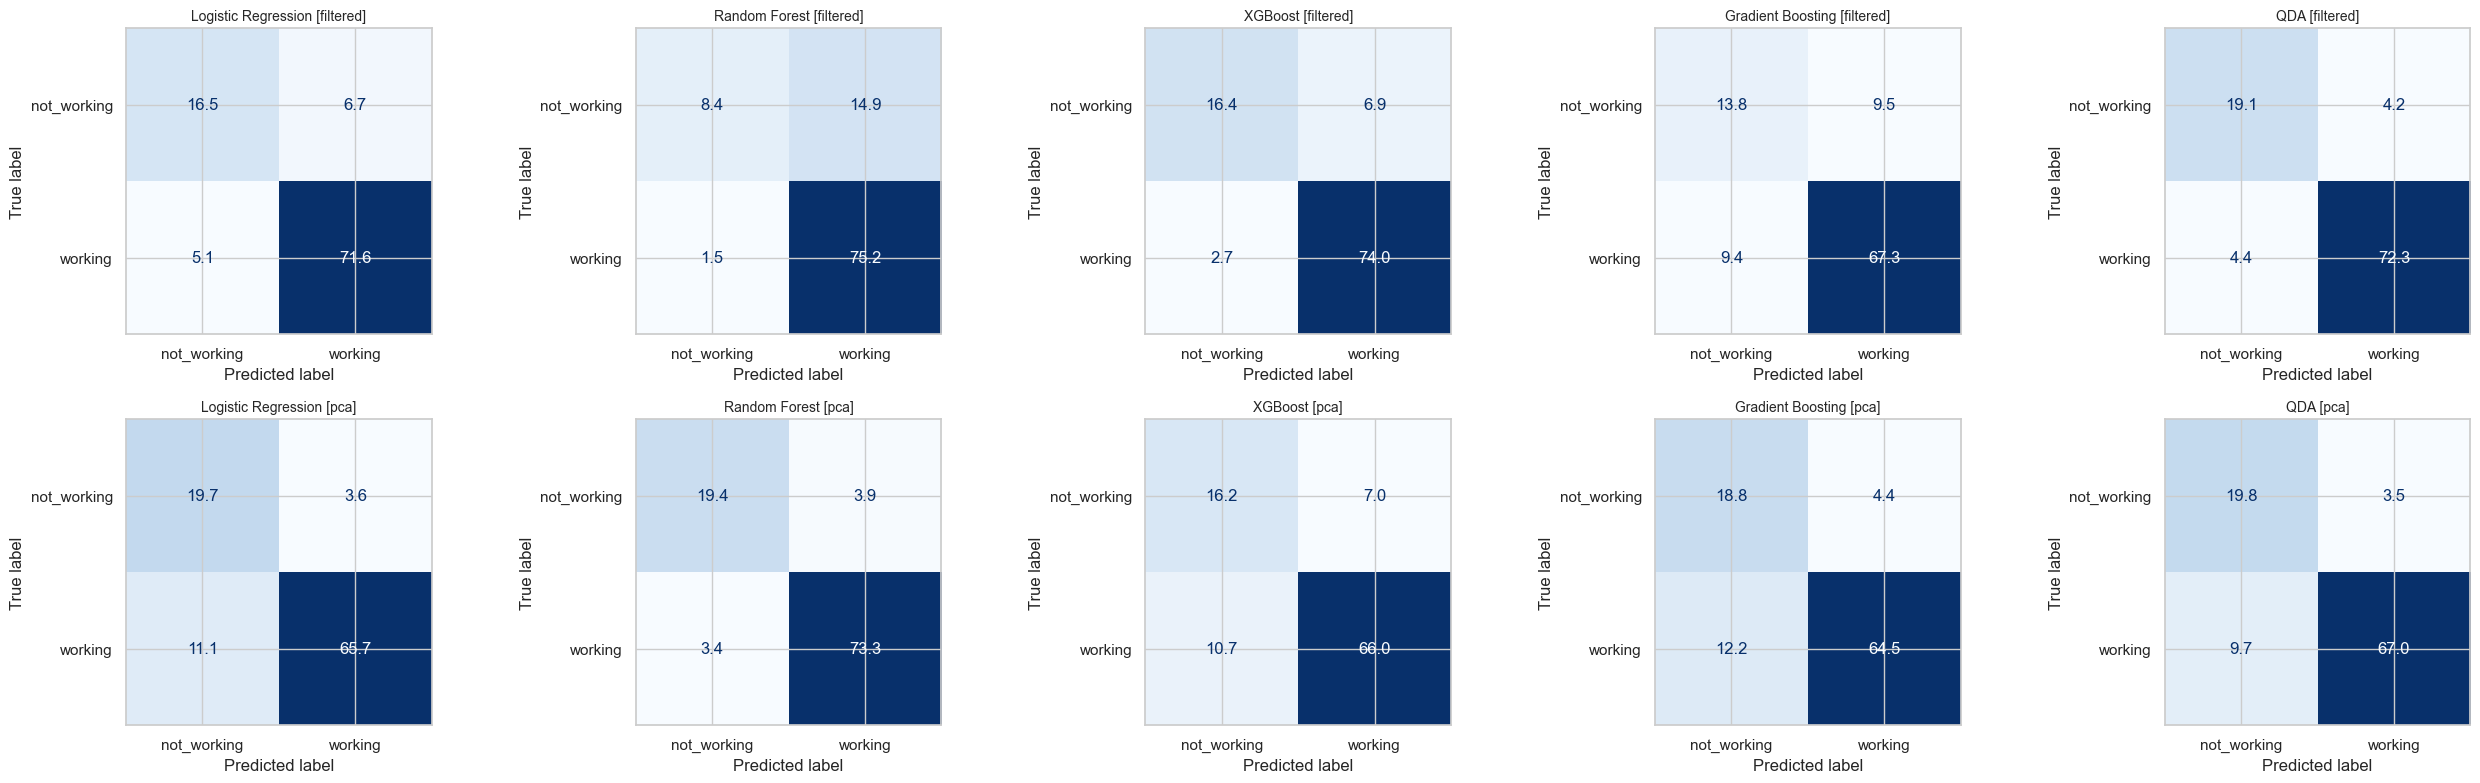

In [6]:
MODEL_KEYS = [
    ("logreg", "Logistic Regression"),
    ("rf",     "Random Forest"),
    ("xgb",    "XGBoost"),
    ("gb",     "Gradient Boosting"),
    ("qda",    "QDA"),
]

for name in ["filtered", "pca"]:
    y_te = splits[name]["y_test"]
    for model_key, model_label in MODEL_KEYS:
        print(f"=== [{name}] {model_label} ===")
        print(classification_report(y_te, preds[name][model_key][0], digits=3))
    print()

labels_order = sorted(splits["filtered"]["y_test"].unique())
fig, axes = plt.subplots(2, 5, figsize=(26, 8))
for r, name in enumerate(["filtered", "pca"]):
    y_te = splits[name]["y_test"]
    for c, (model_key, model_label) in enumerate(MODEL_KEYS):
        cm = confusion_matrix(y_te, preds[name][model_key][0], labels=labels_order)
        total = cm.sum()
        cm_pct = (cm.astype(float) / total * 100) if total else cm.astype(float)
        ConfusionMatrixDisplay(cm_pct, display_labels=labels_order).plot(
            ax=axes[r, c], cmap="Blues", colorbar=False, values_format=".1f",
        )
        axes[r, c].set_title(f"{model_label} [{name}]", fontsize=10)
plt.tight_layout()
plt.show()


### ROC curves (positive class = `not_working`)

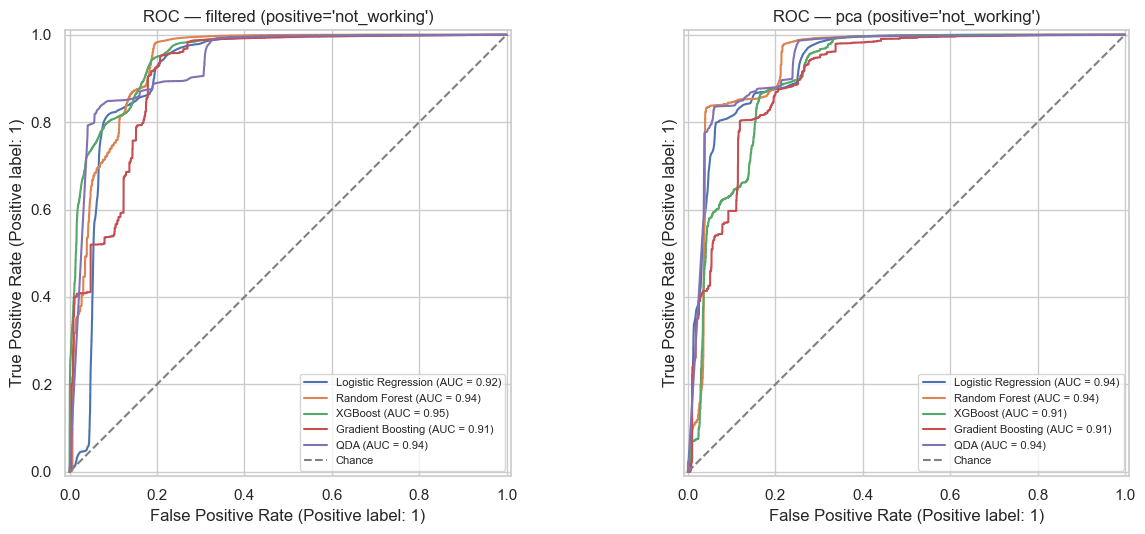

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
for ax, name in zip(axes, ["filtered", "pca"]):
    y_te = splits[name]["y_test"]
    y_true_bin = (y_te == POSITIVE_LABEL).astype(int)
    for model_key, model_label in MODEL_KEYS:
        proba = preds[name][model_key][1]
        if proba is None:
            continue
        RocCurveDisplay.from_predictions(y_true_bin, proba, ax=ax, name=model_label)
    ax.plot([0, 1], [0, 1], ls="--", color="grey", label="Chance")
    ax.set_title(f"ROC — {name} (positive='{POSITIVE_LABEL}')")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 5. Feature importance — side-by-side

We display importance for the three models that expose a natural ranking:

- **Logistic-regression coefficients** — signed (red ⇒ pushes toward
  `not_working`, blue ⇒ toward `working`), on standardized features.
- **Random-forest impurity importance** — unsigned, non-linear.
- **XGBoost gain importance** — unsigned, non-linear.

QDA and MLP do not expose a feature-level importance natively; they are
compared via the metrics table, confusion matrices and ROC curves instead.
Gradient Boosting (sklearn) is similar to RF/XGBoost in spirit and is omitted
here to keep the panel readable.

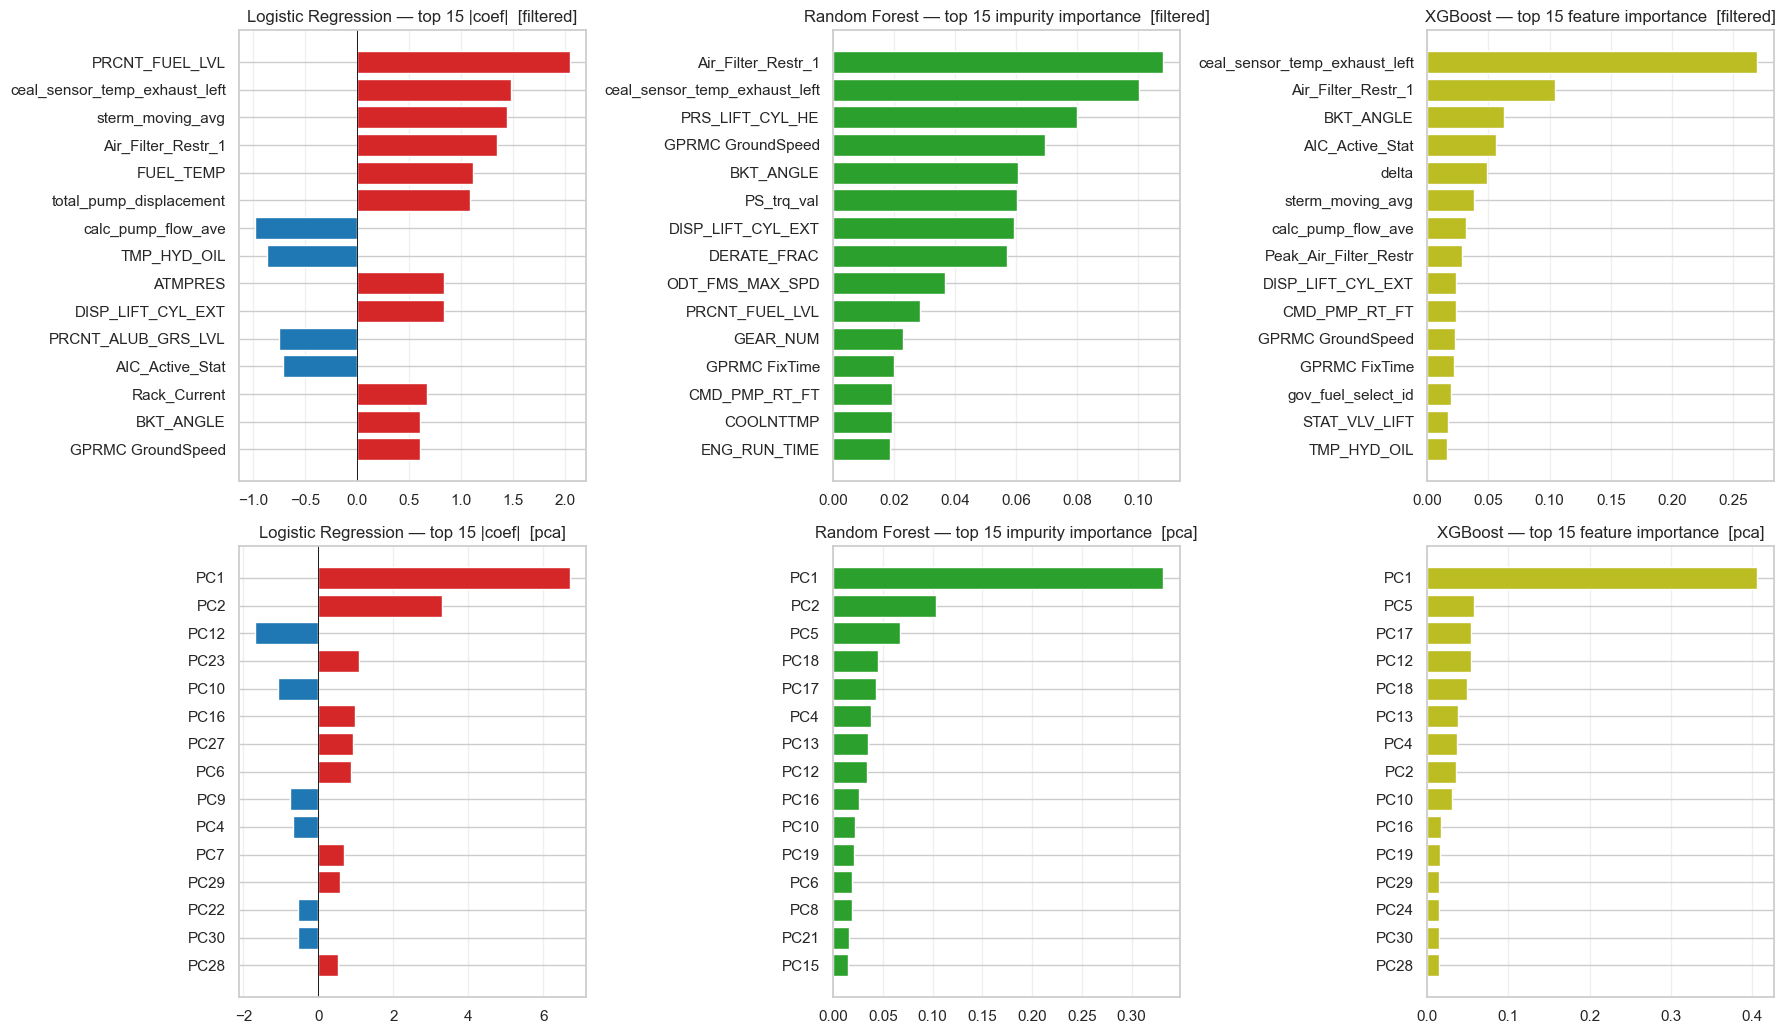

Top 20 — filtered features:


,logreg_coef,logreg_abs,rf_importance,xgb_importance
Air_Filter_Restr_1,1.3461,1.3461,0.1083,0.1043
ceal_sensor_temp_exhaust_left,1.4823,1.4823,0.1002,0.2697
PRS_LIFT_CYL_HE,-0.1102,0.1102,0.0799,0.0151
GPRMC GroundSpeed,0.6008,0.6008,0.0696,0.0228
BKT_ANGLE,0.6049,0.6049,0.0605,0.0630
PS_trq_val,0.0480,0.0480,0.0601,0.0033
DISP_LIFT_CYL_EXT,0.8338,0.8338,0.0592,0.0239
DERATE_FRAC,0.1462,0.1462,0.0569,0.0074
ODT_FMS_MAX_SPD,-0.0983,0.0983,0.0368,0.0038
PRCNT_FUEL_LVL,2.0488,2.0488,0.0286,0.0067


Top 20 — PCA components:


,logreg_coef,logreg_abs,rf_importance,xgb_importance
PC1,6.7172,6.7172,0.3319,0.4063
PC2,3.2894,3.2894,0.1030,0.0352
PC5,0.0326,0.0326,0.0669,0.0574
PC18,-0.0649,0.0649,0.0456,0.0497
PC17,-0.5042,0.5042,0.0427,0.0546
PC4,-0.6749,0.6749,0.0380,0.0364
PC13,-0.4739,0.4739,0.0348,0.0383
PC12,-1.6942,1.6942,0.0343,0.0541
PC16,0.9797,0.9797,0.0256,0.0171
PC10,-1.0814,1.0814,0.0217,0.0305


In [8]:
TOP_K = 15
importance_tables = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 2 * max(4, TOP_K * 0.35)))

for r, name in enumerate(["filtered", "pca"]):
    feat_used = list(splits[name]["X_train"].columns)

    # Logistic-regression coefficients (signed)
    lr_clf = fitted[name]["logreg"].named_steps["clf"]
    pos_idx = list(lr_clf.classes_).index(POSITIVE_LABEL)
    coef = pd.Series(lr_clf.coef_[pos_idx], index=feat_used, name="logreg_coef")
    coef_sorted = coef.reindex(coef.abs().sort_values(ascending=False).index)

    # Random-forest impurity importance
    rf_imp = pd.Series(fitted[name]["rf"].feature_importances_,
                       index=feat_used, name="rf_importance")
    rf_imp_sorted = rf_imp.sort_values(ascending=False)

    # XGBoost gain-based importance
    xgb_imp = pd.Series(fitted[name]["xgb"].feature_importances_,
                        index=feat_used, name="xgb_importance")
    xgb_imp_sorted = xgb_imp.sort_values(ascending=False)

    top_coef = coef_sorted.head(TOP_K).iloc[::-1]
    axes[r, 0].barh(top_coef.index, top_coef.values,
                    color=["tab:red" if v > 0 else "tab:blue" for v in top_coef.values])
    axes[r, 0].set_title(f"Logistic Regression — top {TOP_K} |coef|  [{name}]")
    axes[r, 0].axvline(0, color="k", lw=0.7)
    axes[r, 0].grid(True, axis="x", alpha=0.3)

    top_rf = rf_imp_sorted.head(TOP_K).iloc[::-1]
    axes[r, 1].barh(top_rf.index, top_rf.values, color="tab:green")
    axes[r, 1].set_title(f"Random Forest — top {TOP_K} impurity importance  [{name}]")
    axes[r, 1].grid(True, axis="x", alpha=0.3)

    top_xgb = xgb_imp_sorted.head(TOP_K).iloc[::-1]
    axes[r, 2].barh(top_xgb.index, top_xgb.values, color="tab:olive")
    axes[r, 2].set_title(f"XGBoost — top {TOP_K} feature importance  [{name}]")
    axes[r, 2].grid(True, axis="x", alpha=0.3)

    importance_tables[name] = (
        pd.concat([coef.rename("logreg_coef"),
                   coef.abs().rename("logreg_abs"),
                   rf_imp,
                   xgb_imp], axis=1)
          .sort_values("rf_importance", ascending=False)
    )

plt.tight_layout()
plt.show()

print("Top 20 — filtered features:")
display(importance_tables["filtered"].head(20).round(4))

print("Top 20 — PCA components:")
display(importance_tables["pca"].head(20).round(4))

## 6. Under / overfitting diagnostic — learning curves (side-by-side)

Train and validation `f1_macro` as a function of training-set size, for the
six classifiers and both feature sets. We use `TimeSeriesSplit` so each fold
respects chronological order. Top row: filtered features. Bottom row: PCA scores.

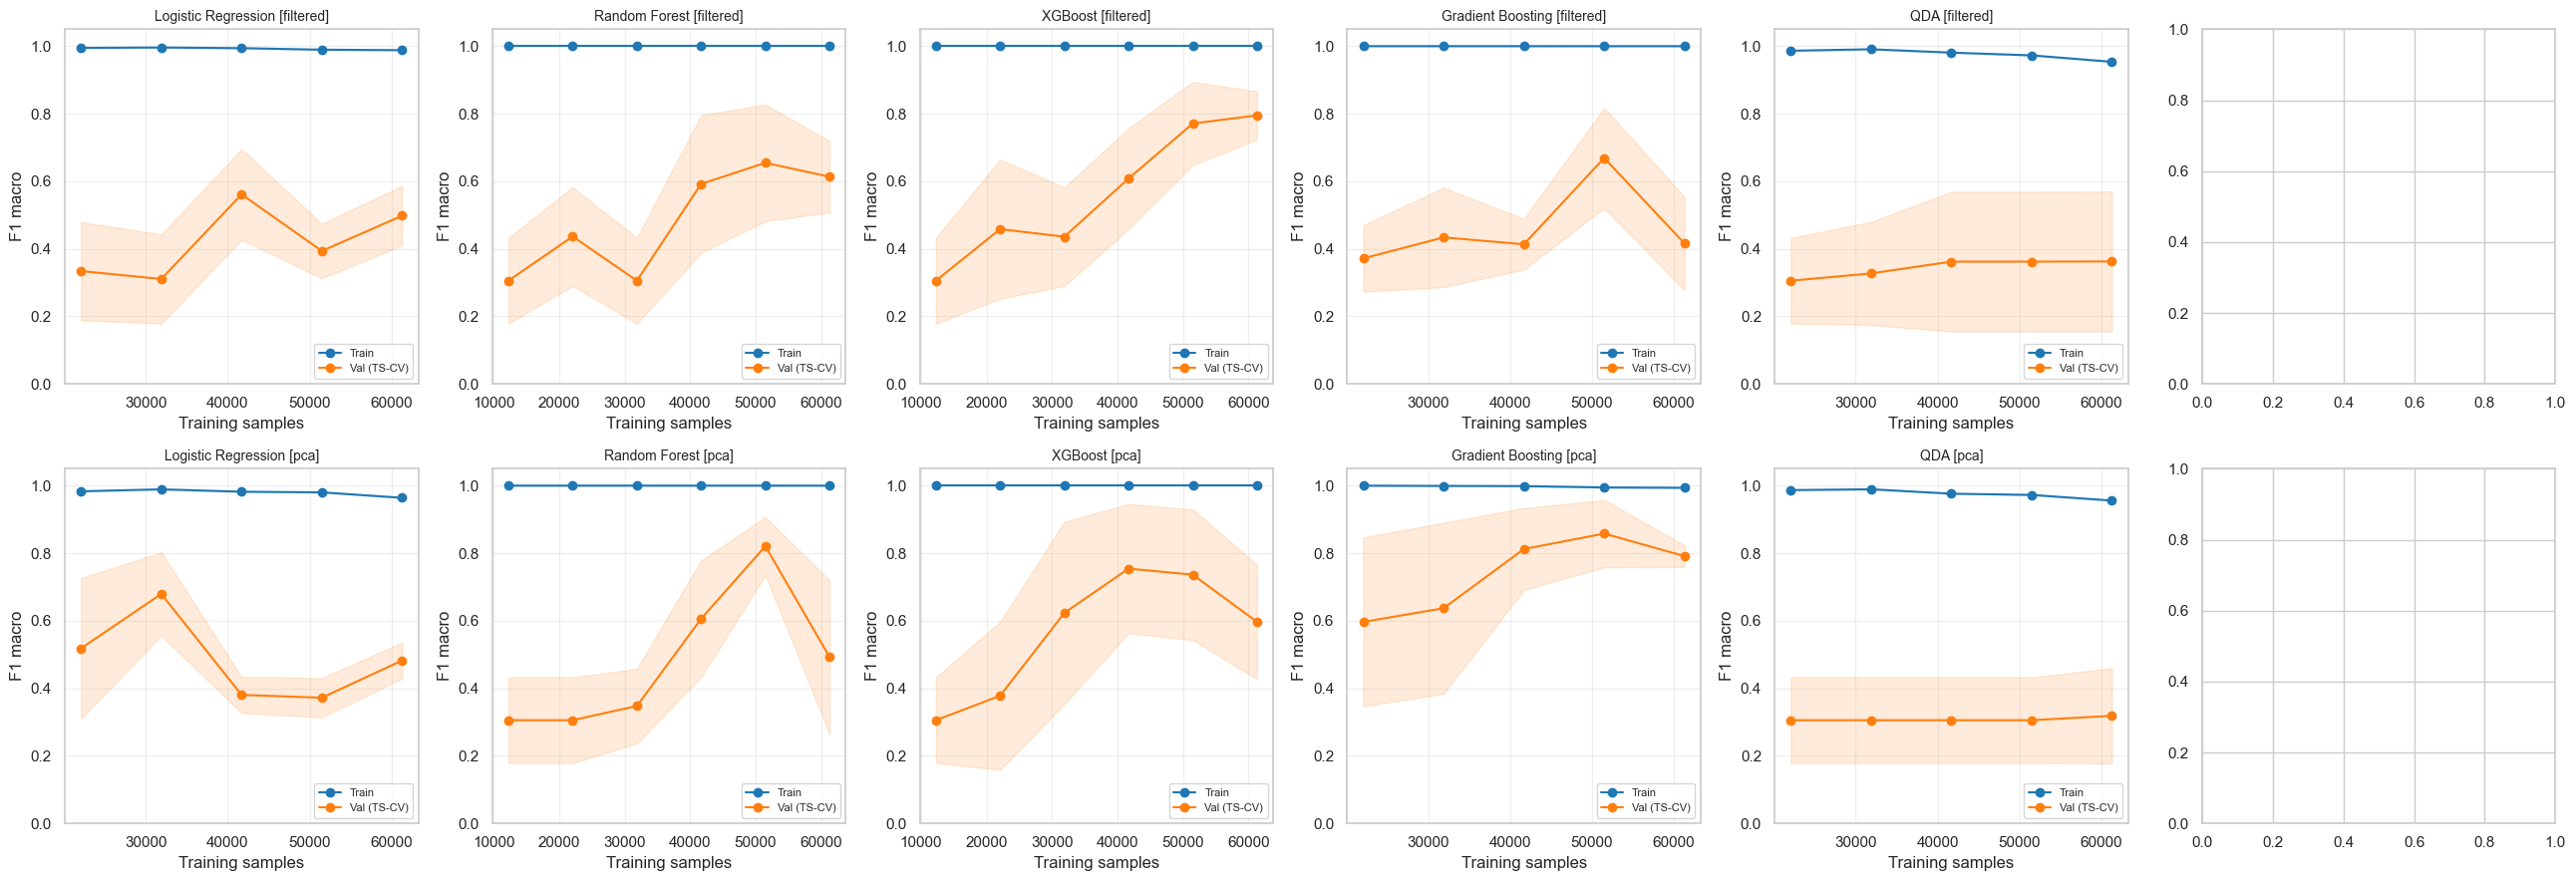

In [9]:
def plot_learning_curve(model, X, y, title, ax):
    sizes, train_sc, val_sc = learning_curve(
        model, X, y,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="f1_macro",
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1,
        shuffle=False,
    )
    ax.plot(sizes, train_sc.mean(axis=1), "o-", label="Train",  color="tab:blue")
    ax.plot(sizes, val_sc.mean(axis=1),   "o-", label="Val (TS-CV)", color="tab:orange")
    ax.fill_between(sizes,
                    train_sc.mean(axis=1) - train_sc.std(axis=1),
                    train_sc.mean(axis=1) + train_sc.std(axis=1),
                    alpha=0.15, color="tab:blue")
    ax.fill_between(sizes,
                    val_sc.mean(axis=1) - val_sc.std(axis=1),
                    val_sc.mean(axis=1) + val_sc.std(axis=1),
                    alpha=0.15, color="tab:orange")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Training samples")
    ax.set_ylabel("F1 macro")
    ax.set_ylim(0, 1.05)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 6, figsize=(26, 9))
for r, name in enumerate(["filtered", "pca"]):
    S = splits[name]
    y_tr_bin = (S["y_train"] == POSITIVE_LABEL).astype(int)
    neg, pos = (y_tr_bin == 0).sum(), (y_tr_bin == 1).sum()
    spw = float(neg) / float(pos) if pos > 0 else 1.0
    for c, (key, label, est) in enumerate(build_models(spw)):
        plot_learning_curve(est, S["X_train"], S["y_train"],
                            f"{label} [{name}]", axes[r, c])
plt.tight_layout()
plt.show()

## 7. Final comparison

All six models from both feature sets in one table, plus a bar chart of the
key metric.

**Primary metric: `f1_macro`** — class-imbalanced dataset (`working`
dominates), and both classes matter operationally (false positives waste
service trips, false negatives miss downtime). `f1_macro` averages F1 across
classes without favouring the majority.

,acc_train,acc_test,bal_acc_test,f1_macro_test,precision_pos,recall_pos,f1_pos,roc_auc
model,,,,,,,,
Logistic Regression [filtered],0.9327,0.8812,0.8217,0.8295,0.7628,0.7104,0.7357,0.9181
Random Forest [filtered],0.9997,0.8358,0.6697,0.7030,0.8474,0.3591,0.5045,0.9391
XGBoost [filtered],0.9997,0.9034,0.8335,0.8553,0.8564,0.7027,0.7720,0.9501
Gradient Boosting [filtered],0.9843,0.8109,0.7350,0.7351,0.5938,0.5932,0.5935,0.9128
QDA [filtered],0.9214,0.9135,0.8806,0.8793,0.8112,0.8191,0.8151,0.9377
Logistic Regression [pca],0.9174,0.8535,0.8509,0.8143,0.6403,0.8459,0.7289,0.9351
Random Forest [pca],0.9992,0.9276,0.8949,0.8978,0.8518,0.8338,0.8427,0.9391
XGBoost [pca],0.9988,0.8222,0.7788,0.7637,0.6018,0.6977,0.6462,0.9080
Gradient Boosting [pca],0.9795,0.8338,0.8254,0.7899,0.6072,0.8097,0.6940,0.9061


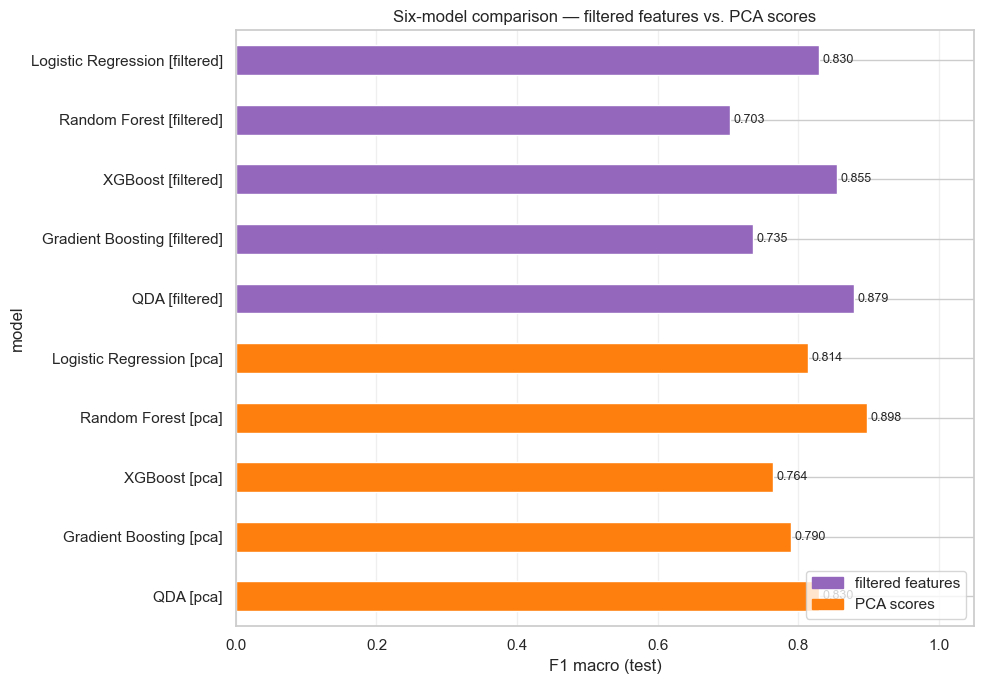


Saved six-model comparison to: C:\Users\alvarjl3\Documents\Repos\Downtime_Analysis\M9P00224_avance4_results.csv


In [10]:
summary = results_df.copy()
display(summary)

def _bar_color(model_name: str) -> str:
    if "[pca]" in model_name.lower():
        return "tab:orange"
    if "[filtered]" in model_name.lower():
        return "tab:purple"
    return "tab:grey"

colors = [_bar_color(m) for m in summary.index]

fig, ax = plt.subplots(figsize=(10, 7))
summary["f1_macro_test"].plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("F1 macro (test)")
ax.set_title("Six-model comparison — filtered features vs. PCA scores")
ax.invert_yaxis()
for i, v in enumerate(summary["f1_macro_test"].values):
    if np.isfinite(v):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)
ax.set_xlim(0, 1.05)
ax.grid(True, axis="x", alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="tab:purple", label="filtered features"),
    Patch(color="tab:orange", label="PCA scores"),
], loc="lower right")

plt.tight_layout()
plt.show()

summary_out = Path(f"{SERIAL_NUMBER}_avance4_results.csv")
summary.to_csv(summary_out)
print(f"\nSaved six-model comparison to: {summary_out.resolve()}")

## 8. Conclusions

Basado en que es importante no fallar en detectar un downtime, pero a la vez queremos ser tambien precisos en detectar cuando la maquina esta activa y reportar con la mayor precisión posible, la metrica prioritaria para evaluar los modelos ha sido F1. Con esta metrica, el modelo que mejor rendimiento tiene es XGBoost.

Debido a que XGBoos es un modelo basado en arboles, dejaremos de utilizar en el futuro el dataset de PCA, ya que los arboles suelen ser invariantes a este, ademas de que la interpretabilidad del modelo se vuelve imposible. Tambien estariamos disupuestos a reducir la precisión del modelo si esto logra reducir la cantidad de features necesarias, pues los canales dispinbles no son los mismos en las maquinas y la repetibilidad se vuelve un problema.